In [1]:
#Install Package
!pip install yfinance
!pip install yahoofinancials

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=591875ef5a8476b43fb59621ef6e56558a50520d176046943f338cf017c66109
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [2]:
import yfinance as yf
from yahoofinancials import YahooFinancials

import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np
import plotly.graph_objects as go

In [3]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Step added because of Wikipedia blocking pandas user-agent
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
table = pd.read_html(response.text)[0]

# Creating a dictionary with the Symbol and Security columns

sp500_dict = dict(zip(table.iloc[:, 0], table.iloc[:, 1]))

# Extracting the ticker list

tickerlist = list(sp500_dict.keys())

/tmp/ipykernel_820/1251342058.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)[0]


In [5]:
sp500_dict

{'MMM': '3M',
 'AOS': 'A. O. Smith',
 'ABT': 'Abbott Laboratories',
 'ABBV': 'AbbVie',
 'ACN': 'Accenture',
 'ADBE': 'Adobe Inc.',
 'AMD': 'Advanced Micro Devices',
 'AES': 'AES Corporation',
 'AFL': 'Aflac',
 'A': 'Agilent Technologies',
 'APD': 'Air Products',
 'ABNB': 'Airbnb',
 'AKAM': 'Akamai Technologies',
 'ALB': 'Albemarle Corporation',
 'ARE': 'Alexandria Real Estate Equities',
 'ALGN': 'Align Technology',
 'ALLE': 'Allegion',
 'LNT': 'Alliant Energy',
 'ALL': 'Allstate',
 'GOOGL': 'Alphabet Inc. (Class A)',
 'GOOG': 'Alphabet Inc. (Class C)',
 'MO': 'Altria',
 'AMZN': 'Amazon',
 'AMCR': 'Amcor',
 'AEE': 'Ameren',
 'AEP': 'American Electric Power',
 'AXP': 'American Express',
 'AIG': 'American International Group',
 'AMT': 'American Tower',
 'AWK': 'American Water Works',
 'AMP': 'Ameriprise Financial',
 'AME': 'Ametek',
 'AMGN': 'Amgen',
 'APH': 'Amphenol',
 'ADI': 'Analog Devices',
 'AON': 'Aon plc',
 'APA': 'APA Corporation',
 'APO': 'Apollo Global Management',
 'AAPL': 'Ap

In [6]:
tickerlist

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 '

In [7]:
# Define a start date and End Date
start = '2022-01-01'
end = '2025-01-01'

In [8]:
df = yf.download(tickers=tickerlist, start= start , end = end)

/tmp/ipykernel_820/29310503.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=tickerlist, start= start , end = end)
[**********************79%*************          ]  399 of 503 completedERROR:yfinance:Failed to get ticker 'WSM' reason: Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[**********************82%**************         ]  413 of 503 completedERROR:yfinance:Failed to get ticker 'J' reason: Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
5 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDat

In [9]:
df

Price      Adj Close                          Close                          \
Ticker          BF.B BRK.B   J   Q SNDK           A        AAPL        ABBV   
Date                                                                          
2022-01-03       NaN   NaN NaN NaN  NaN  151.702164  178.103683  114.894058   
2022-01-04       NaN   NaN NaN NaN  NaN  146.573685  175.843231  114.673454   
2022-01-05       NaN   NaN NaN NaN  NaN  144.062759  171.165817  115.275818   
2022-01-06       NaN   NaN NaN NaN  NaN  144.566879  168.308487  114.732834   
2022-01-07       NaN   NaN NaN NaN  NaN  140.718079  168.474823  114.435905   
...              ...   ...  ..  ..  ...         ...         ...         ...   
2024-12-24       NaN   NaN NaN NaN  NaN  134.457260  256.797211  171.111115   
2024-12-26       NaN   NaN NaN NaN  NaN  134.190506  257.612732  170.350601   
2024-12-27       NaN   NaN NaN NaN  NaN  133.904007  254.201355  169.219360   
2024-12-30       NaN   NaN NaN NaN  NaN  132.797531  250.829773  167.498764   
2024-12-31       NaN   NaN NaN NaN  NaN  132.963806  249.059464  168.924698   

Price                               ...   Volume                              \
Ticker            ABNB         ABT  ...       WY     WYNN      XEL       XOM   
Date                                ...                                        
2022-01-03  172.679993  127.545799  ...  3831100  2437800  3501100  24282400   
2022-01-04  170.800003  124.546150  ...  3089700  2292300  4197000  38584000   
2022-01-05  162.250000  123.986580  ...  3737600  3439900  4166000  34033300   
2022-01-06  159.750000  123.968208  ...  3315200  2583200  2296000  30668500   
2022-01-07  166.050003  124.353508  ...  3309900  1720400  2673100  23985400   
...                ...         ...  ...      ...      ...      ...       ...   
2024-12-24  134.990005  111.359657  ...  1780100   692800   943900   7807000   
2024-12-26  135.320007  111.854538  ...  1736500  1218900  1394900   9652400   
2024-12-27  133.384995  111.582840  ...  2320500  1086700  2015000  11943900   
2024-12-30  131.809998  109.457741  ...  2914700  2180100  2642900  11080800   
2024-12-31  131.410004  109.758545  ...  3125200  1612600  2143800  12387800   

Price                                                             
Ticker          XYL       XYZ      YUM      ZBH    ZBRA      ZTS  
Date                                                              
2022-01-03   759100   7315700  1251400  1184809  272600  2772700  
2022-01-04   925400  14768500   935900  1400800  346000  4664000  
2022-01-05  1090200  17546200   977900  1895715  403700  4749400  
2022-01-06   703400  16244200   862400  1088813  338300  3103400  
2022-01-07   765000   9426000   833700  1690230  432800  2206500  
...             ...       ...      ...      ...     ...      ...  
2024-12-24   379300   2197700   533000   458600   88700  1023600  
2024-12-26   575700   2991100  1040900  1277300  140100  2167200  
2024-12-27   552400   4140800  1146300   743400  287200  1800100  
2024-12-30   586800   5383800  1144600  1532000  211300  1531400  
2024-12-31   641600   4989400  1217100   683300  327900  1327400  

[753 rows x 2520 columns]

In [10]:
df.describe()

Price  Adj Close                            Close                          \
Ticker      BF.B BRK.B    J    Q SNDK           A        AAPL        ABBV   
count        0.0   0.0  0.0  0.0  0.0  753.000000  753.000000  753.000000   
mean         NaN   NaN  NaN  NaN  NaN  130.064352  176.028011  142.982799   
std          NaN   NaN  NaN  NaN  NaN   11.427630   29.480788   19.102366   
min          NaN   NaN  NaN  NaN  NaN   99.275681  123.046822  113.137421   
25%          NaN   NaN  NaN  NaN  NaN  122.859200  153.404877  128.927185   
50%          NaN   NaN  NaN  NaN  NaN  130.553513  171.187943  136.903625   
75%          NaN   NaN  NaN  NaN  NaN  137.322266  189.590439  156.163971   
max          NaN   NaN  NaN  NaN  NaN  155.217957  257.612732  193.802322   

Price                           ...        Volume                              \
Ticker        ABNB         ABT  ...            WY          WYNN           XEL   
count   753.000000  753.000000  ...  7.530000e+02  7.530000e+02  7.530000e+02   
mean    130.588958  103.078832  ...  3.893122e+06  2.591136e+06  3.640352e+06   
std      20.996819    7.302950  ...  1.592697e+06  1.590913e+06  1.980737e+06   
min      82.489998   85.805328  ...  9.679000e+05  6.928000e+05  9.439000e+05   
25%     115.940002   98.070808  ...  2.965000e+06  1.628700e+06  2.545100e+06   
50%     129.699997  102.208000  ...  3.581300e+06  2.180100e+06  3.173400e+06   
75%     146.699997  108.607040  ...  4.446600e+06  2.983000e+06  4.139200e+06   
max     186.639999  127.545799  ...  1.834140e+07  1.505450e+07  2.278220e+07   

Price                                                                         \
Ticker           XOM           XYL           XYZ           YUM           ZBH   
count   7.530000e+02  7.530000e+02  7.530000e+02  7.530000e+02  7.530000e+02   
mean    1.969823e+07  1.352194e+06  1.245447e+07  1.760692e+06  1.482036e+06   
std     8.634727e+06  1.080534e+06  8.550124e+06  6.757253e+05  7.254535e+05   
min     7.136000e+06  3.211000e+05  2.197700e+06  5.330000e+05  4.279000e+05   
25%     1.397380e+07  8.997000e+05  7.605600e+06  1.330000e+06  1.030800e+06   
50%     1.743320e+07  1.144400e+06  1.055780e+07  1.618100e+06  1.317600e+06   
75%     2.241530e+07  1.533100e+06  1.489760e+07  2.017300e+06  1.726300e+06   
max     7.208230e+07  2.024170e+07  1.403139e+08  7.448300e+06  7.107800e+06   

Price                               
Ticker          ZBRA           ZTS  
count   7.530000e+02  7.530000e+02  
mean    4.021021e+05  2.221513e+06  
std     2.082815e+05  1.059138e+06  
min     8.870000e+04  6.352000e+05  
25%     2.766000e+05  1.560900e+06  
50%     3.554000e+05  1.951100e+06  
75%     4.785000e+05  2.540900e+06  
max     2.621700e+06  1.157780e+07  

[8 rows x 2520 columns]

In [11]:
df = df.drop(columns='Adj Close')

In [12]:
# A3 - Identify and remove invalid data

print("Shape before cleaning:", df.shape)
print("Missing values per column (sample):")
print(df.isnull().sum().sum(), "total missing values")

# Drop ticker columns where more than 50% of values are missing
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=int(threshold))

# Forward fill remaining missing values (carries last known price forward)
df = df.ffill()

# Drop any remaining rows with NaN
df = df.dropna()

Shape before cleaning: (753, 2515)
Missing values per column (sample):
29550 total missing values


In [13]:
df

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2023-05-04  130.859009  163.422455  132.336411  117.629997  104.389168   
2023-05-05  130.292099  171.091400  132.938080  119.900002  104.765800   
2023-05-08  129.461258  171.022369  132.417221  125.650002  104.426842   
2023-05-09  124.476349  169.317078  131.860428  127.070000  103.814774   
2023-05-10  125.170334  171.081528  131.492249  113.190002  104.229088   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457260  256.797211  171.111115  134.990005  111.359657   
2024-12-26  134.190506  257.612732  170.350601  135.320007  111.854538   
2024-12-27  133.904007  254.201355  169.219360  133.384995  111.582840   
2024-12-30  132.797531  250.829773  167.498764  131.809998  109.457741   
2024-12-31  132.963806  249.059464  168.924698  131.410004  109.758545   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2023-05-04  69.339516  254.434708  335.829987  172.395798  67.246979  ...   
2023-05-05  71.136719  253.623199  348.399994  174.354279  68.823494  ...   
2023-05-08  72.401413  252.830795  344.059998  175.428574  68.316109  ...   
2023-05-09  72.848335  251.551422  342.649994  170.769974  67.971817  ...   
2023-05-10  73.428383  256.716553  344.019989  172.490829  67.627518  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541504  447.940002  213.882050  48.364086  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344978  ...   
2024-12-27  92.339996  348.213348  446.480011  212.803284  48.316319  ...   
2024-12-30  91.889999  344.605927  445.799988  208.458771  47.829144  ...   
2024-12-31  92.349998  343.921570  444.679993  208.360687  48.259007  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2023-05-04  3873700  1644000  3463900  17177200  2583600  16023900  1555600   
2023-05-05  3053300  1561100  2147900  14968200  2884900  25485600  1361600   
2023-05-08  3942900  1836700  2171000  11187800  1523300  13623600   981400   
2023-05-09  5347400  3359700  2102800  11370800  1452700   8377200  1094900   
2023-05-10  4935700  5041500  2963100  14884800  1344700  12457000  1595200   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2023-05-04  1410500  551700  3592200  
2023-05-05   995900  486300  4224400  
2023-05-08  1304500  384100  1976100  
2023-05-09  1017600  432900  1904200  
2023-05-10  1163400  257400  1610500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[418 rows x 2475 columns]

In [14]:
df.to_csv('S&P500.csv')

In [15]:
stock_open = np.array(df['Open']).T # stock_open is numpy array of transpose of p['Open']
stock_close = np.array(df['Close']).T # stock_close is numpy array of transpose of p['Close']

In [16]:
movements = stock_close - stock_open
movements

array([[-1.46615257, -1.95487016, -1.52479616, ...,  0.90889366,
         0.01976282, -0.46518649],
       [ 0.88714167,  2.55302582,  1.00543831, ..., -2.22782018,
        -0.02983579, -2.00902957],
       [-1.4727988 , -0.45799967, -0.62863108, ...,  0.08555207,
        -0.77951314,  1.2833247 ],
       ...,
       [-1.78137412,  0.73981442,  0.21415525, ...,  0.41383971,
        -0.64190047, -0.27651665],
       [ 8.79998779,  4.69998169,  3.85998535, ..., -4.29998779,
        -1.20999146,  2.79998779],
       [10.09729789,  6.00822563, -1.38874225, ..., -0.34244273,
        -1.61440901,  0.02935181]])

In [17]:
sum_of_movement = np.sum(movements,1)

for i in range(len(sum_of_movement)):
  print('company:{}, Change:{}'.format(df['High'].columns[i],sum_of_movement[i]))

company:A, Change:4.590537792871757
company:AAPL, Change:89.11212896568
company:ABBV, Change:17.24233182777901
company:ABNB, Change:80.47412872314453
company:ABT, Change:3.96044442723543
company:ACGL, Change:-27.700382202889003
company:ACN, Change:77.14854736155564
company:ADBE, Change:84.149658203125
company:ADI, Change:3.998271095558806
company:ADM, Change:-13.040630434190838
company:ADP, Change:-1.1147378957471403
company:ADSK, Change:78.82014465332031
company:AEE, Change:-5.693963696150185
company:AEP, Change:-6.613703682144106
company:AES, Change:-12.62491125572643
company:AFL, Change:16.357031694784204
company:AIG, Change:1.371286796407631
company:AIZ, Change:13.45007251085157
company:AJG, Change:16.371283822944093
company:AKAM, Change:2.5399627685546875
company:ALB, Change:-115.1011409778397
company:ALGN, Change:-101.0699462890625
company:ALL, Change:-11.082798198721235
company:ALLE, Change:-0.39283849108407765
company:AMAT, Change:-41.59029908550035
company:AMCR, Change:-7.4931

In [18]:
daily_returns = (df["Close"] - df["Close"].shift(1)) / df["Close"].shift(1)

In [19]:
daily_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05-05,-0.004332,0.046927,0.004547,0.019298,0.003608,0.025919,-0.003189,0.037430,0.011360,0.023444,...,0.022751,0.014005,0.006656,0.024896,0.024828,-0.019527,0.008583,0.009368,0.033208,0.043481
2023-05-08,-0.006377,-0.000403,-0.003918,0.047957,-0.003235,0.017778,-0.003124,-0.012457,0.006162,-0.007372,...,0.002696,0.017873,-0.003594,0.003957,-0.014958,-0.007595,-0.006982,-0.003408,0.014828,-0.007303
2023-05-09,-0.038505,-0.009971,-0.004205,0.011301,-0.005861,0.006173,-0.005060,-0.004098,-0.026556,-0.005040,...,0.007059,-0.009401,-0.003029,0.000275,-0.005031,0.008844,0.007910,-0.010114,-0.027712,-0.002705
2023-05-10,0.005575,0.010421,-0.002792,-0.109231,0.003991,0.007962,0.020533,0.003998,0.010077,-0.005065,...,0.004673,-0.001790,0.002749,-0.012828,0.000093,-0.030175,0.000945,0.010070,0.005959,0.004177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002556
2024-12-26,-0.001984,0.003176,-0.004445,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000138,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007407,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011792,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007935,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


In [31]:
daily_returns.to_csv('daily_returns.csv')

**Calculating BETA**

In [23]:
index = yf.download('^GSPC', start=start, end=end)['Close'].squeeze()
index_returns = index.pct_change().dropna()
index_returns.name = 'GSPC'

# Calculate beta for each stock
betas = {}

# Filter tickerlist to include only tickers present in daily_returns
available_tickers = [t for t in tickerlist if t in daily_returns.columns]

for ticker in available_tickers:
    stock_returns = daily_returns[ticker].dropna()
    aligned = pd.concat([stock_returns, index_returns], axis=1, join='inner').dropna()
    # Ensure there's enough data to compute covariance and variance
    if not aligned.empty and 'GSPC' in aligned.columns and len(aligned) > 1:
        cov_matrix = np.cov(aligned[ticker], aligned['GSPC'])
        # Ensure the variance of GSPC is not zero to avoid division by zero
        if np.var(aligned['GSPC']) != 0:
            beta = cov_matrix[0, 1] / np.var(aligned['GSPC'])
            betas[ticker] = beta
        else:
            print(f"Skipping {ticker}: Variance of GSPC returns is zero after alignment.")
    else:
        print(f"Skipping {ticker}: Not enough aligned data with GSPC.")

betas_df = pd.Series(betas, name='Beta').to_frame()

/tmp/ipykernel_820/4166356053.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  index = yf.download('^GSPC', start=start, end=end)['Close'].squeeze()
[*********************100%***********************]  1 of 1 completed


In [24]:
betas_df

,Beta
MMM,0.872529
AOS,0.852687
ABT,0.261883
ABBV,0.238555
ACN,0.774229
...,...
XYL,0.984842
YUM,0.537993
ZBRA,1.416668
ZBH,0.579353


In [32]:
betas_df.to_csv('betas.csv')

**Calculating Anual Volatility**

In [25]:
annual_volatility = daily_returns.std() * np.sqrt(252)
annual_volatility_df = annual_volatility.to_frame(name='Annual Volatility')

In [26]:
annual_volatility_df

,Annual Volatility
Ticker,
A,0.262364
AAPL,0.211885
ABBV,0.216108
ABNB,0.356680
ABT,0.179846
...,...
XYZ,0.473401
YUM,0.161240
ZBH,0.215355


In [33]:
annual_volatility_df.to_csv('annual_volatility.csv')

**Illustration of metrics** (following method shown in lecture/seminar)

## A7 - Illustration of Metrics: Discussion

The three metrics — **Daily Return**, **Beta**, and **Annual Volatility** — are essential tools for investors seeking to balance risk and reward in a stock portfolio.

- **Daily Return** measures how much a stock gains or loses each day relative to its previous price. Stocks with consistently higher average daily returns are more attractive to growth-oriented investors, while those with lower or negative returns may signal underperformance.

- **Beta** measures a stock's sensitivity to market movements relative to the S&P 500 benchmark. A beta greater than 1 indicates the stock is more volatile than the market, making it riskier but potentially more rewarding. A beta below 1 suggests the stock is more stable and less affected by market swings, making it suitable for risk-averse investors.

- **Annual Volatility** quantifies the degree of price fluctuation over a year. High volatility stocks carry greater uncertainty and risk, while low volatility stocks offer more predictable, stable returns.

By clustering stocks using these three metrics with agglomerative clustering, investors can identify natural groupings — for example, a cluster of low-beta, low-volatility stocks suitable for conservative portfolios, versus a cluster of high-beta, high-return stocks suited for aggressive growth strategies. This segmentation enables investors to build diversified portfolios that align with their specific risk tolerance.

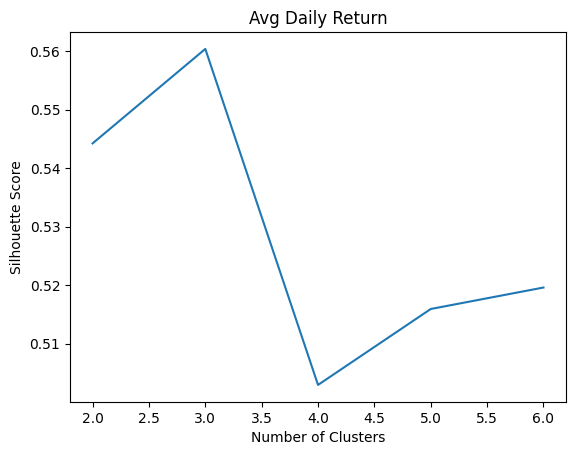

Cluster 1 has 199 observations
Cluster 2 has 296 observations


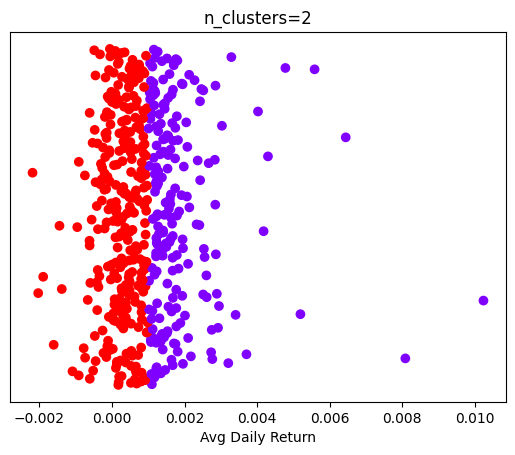

Cluster 1 has 296 observations
Cluster 2 has 190 observations
Cluster 3 has 9 observations


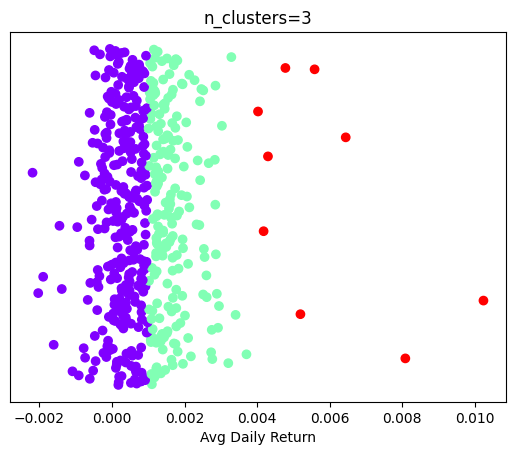

Cluster 1 has 190 observations
Cluster 2 has 213 observations
Cluster 3 has 9 observations
Cluster 4 has 83 observations


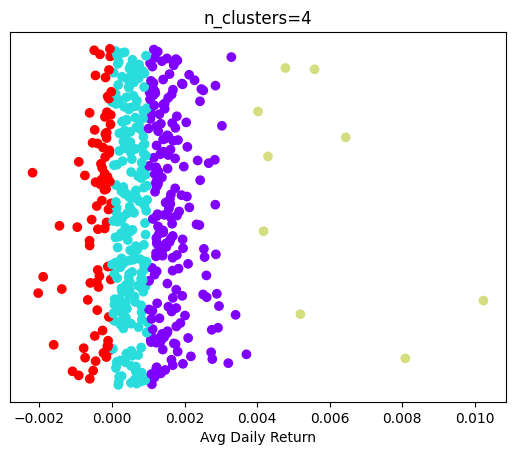

Cluster 1 has 9 observations
Cluster 2 has 213 observations
Cluster 3 has 47 observations
Cluster 4 has 83 observations
Cluster 5 has 143 observations


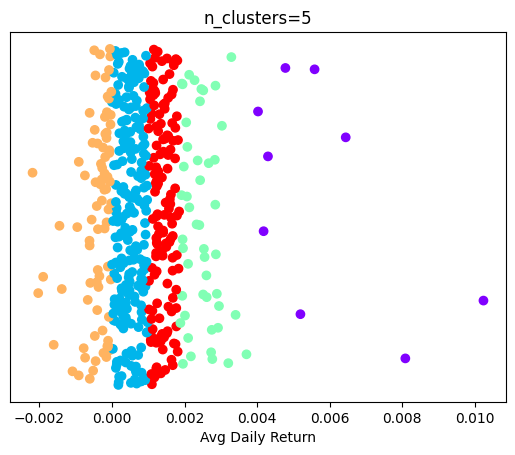

Cluster 1 has 213 observations
Cluster 2 has 83 observations
Cluster 3 has 47 observations
Cluster 4 has 7 observations
Cluster 5 has 143 observations
Cluster 6 has 2 observations


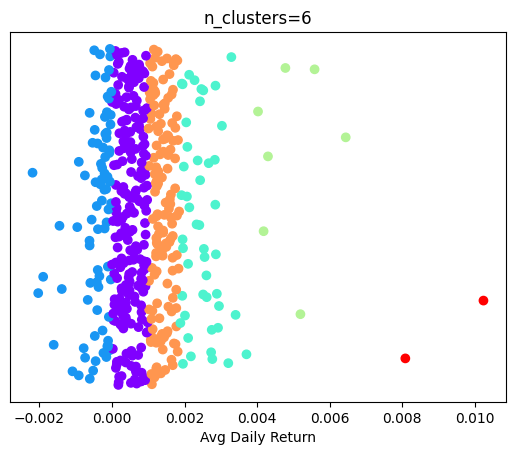

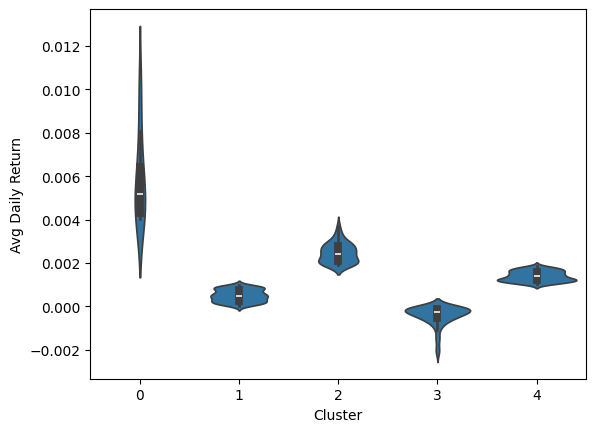

In [27]:
# Daily Return

daily_returns_mean = daily_returns.mean().to_frame(name='Avg Daily Return')
X = daily_returns_mean[['Avg Daily Return']]
range_n_clusters = [2, 3, 4, 5, 6]

scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit(X).labels_
    scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Avg Daily Return')
plt.show()

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(X, daily_returns_mean.index, c=labels, cmap='rainbow')
    plt.xlabel('Avg Daily Return')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
daily_returns_mean['Cluster'] = agglom.fit_predict(X)

sns.violinplot(x='Cluster', y='Avg Daily Return', data=daily_returns_mean)
plt.show()

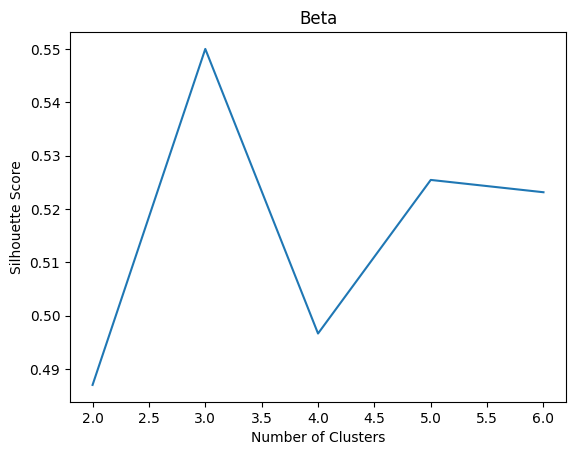

Cluster 1 has 290 observations
Cluster 2 has 205 observations


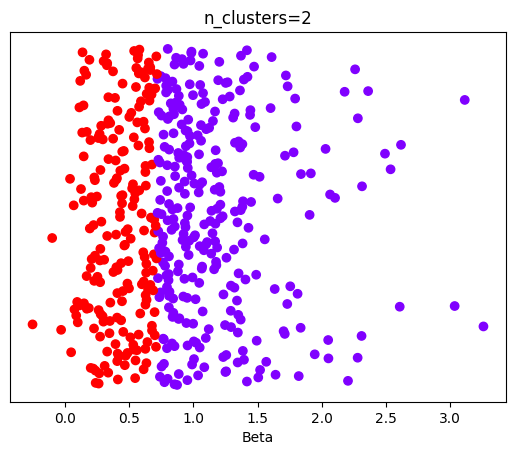

Cluster 1 has 246 observations
Cluster 2 has 205 observations
Cluster 3 has 44 observations


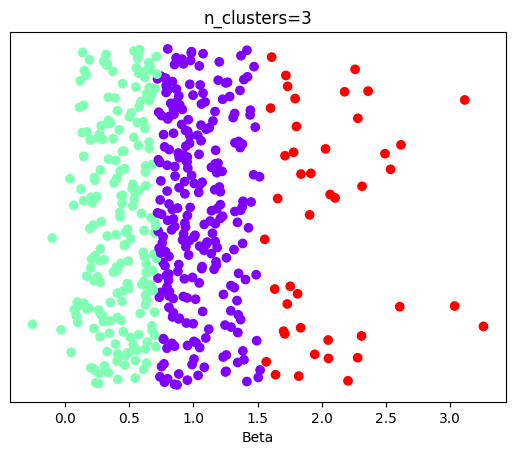

Cluster 1 has 205 observations
Cluster 2 has 111 observations
Cluster 3 has 44 observations
Cluster 4 has 135 observations


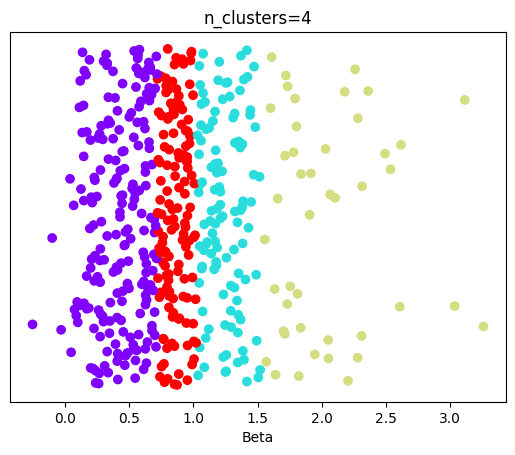

Cluster 1 has 44 observations
Cluster 2 has 111 observations
Cluster 3 has 126 observations
Cluster 4 has 135 observations
Cluster 5 has 79 observations


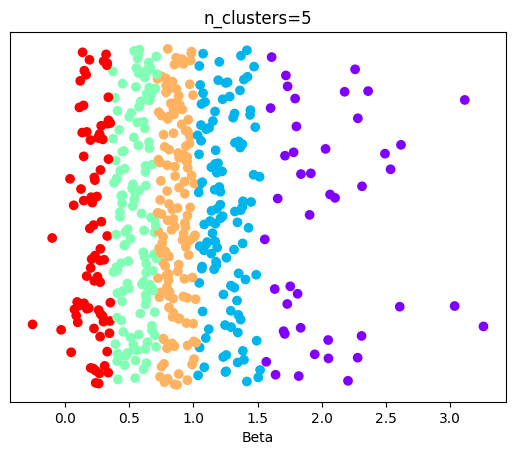

Cluster 1 has 20 observations
Cluster 2 has 111 observations
Cluster 3 has 126 observations
Cluster 4 has 135 observations
Cluster 5 has 79 observations
Cluster 6 has 24 observations


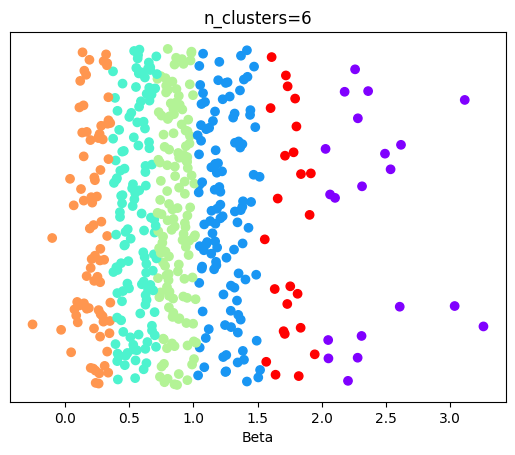

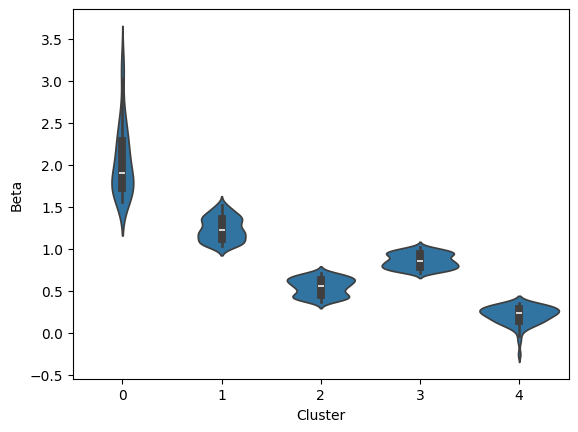

In [29]:
# BETA

X = betas_df[['Beta']]
range_n_clusters = [2, 3, 4, 5, 6]

scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit(X).labels_
    scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Beta')
plt.show()

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(X, X.index, c=labels, cmap='rainbow')
    plt.xlabel('Beta')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
X['Cluster'] = agglom.fit_predict(X)

sns.violinplot(x='Cluster', y='Beta', data=X)
plt.show()

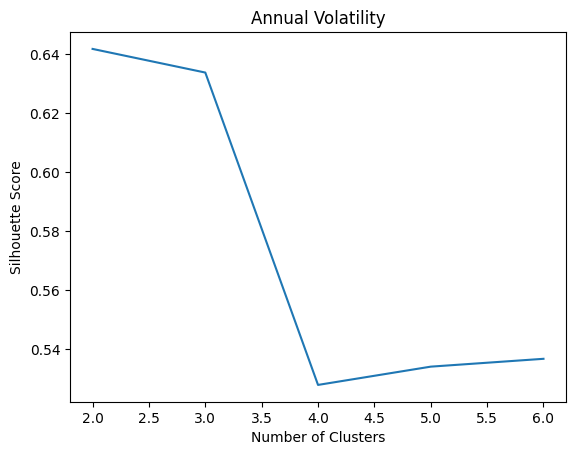

Cluster 1 has 108 observations
Cluster 2 has 387 observations


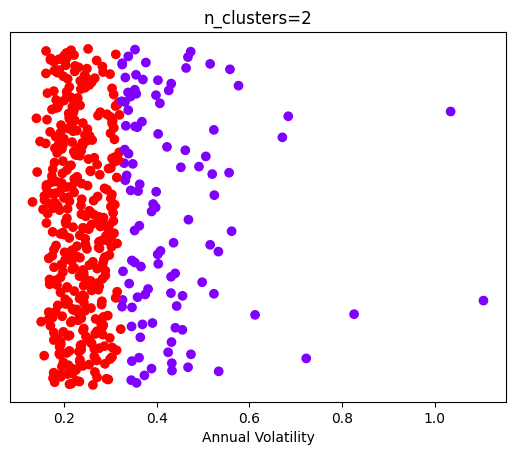

Cluster 1 has 387 observations
Cluster 2 has 102 observations
Cluster 3 has 6 observations


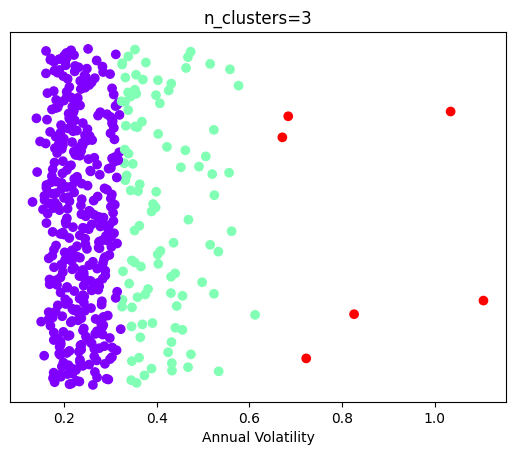

Cluster 1 has 102 observations
Cluster 2 has 203 observations
Cluster 3 has 6 observations
Cluster 4 has 184 observations


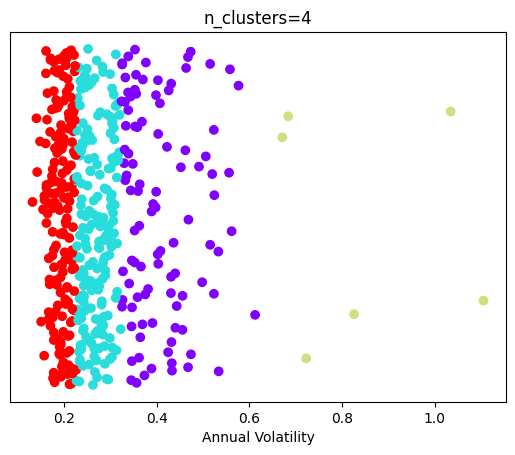

Cluster 1 has 6 observations
Cluster 2 has 203 observations
Cluster 3 has 39 observations
Cluster 4 has 184 observations
Cluster 5 has 63 observations


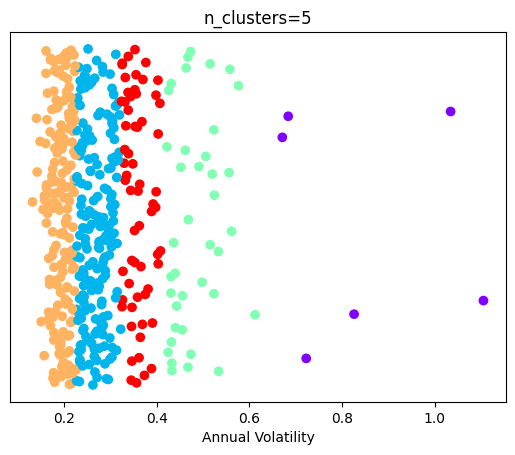

Cluster 1 has 203 observations
Cluster 2 has 184 observations
Cluster 3 has 39 observations
Cluster 4 has 4 observations
Cluster 5 has 63 observations
Cluster 6 has 2 observations


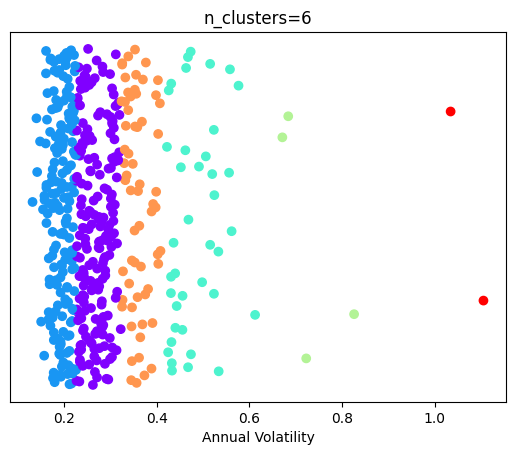

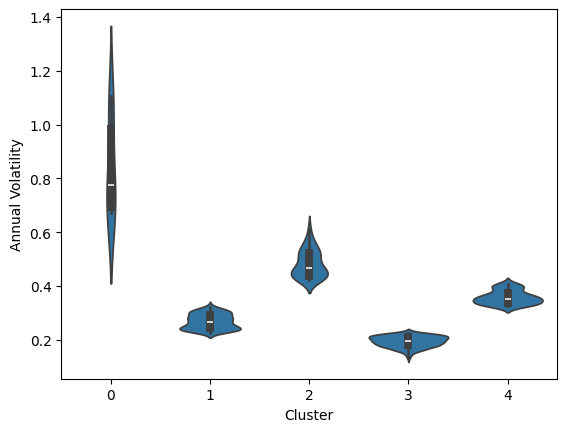

In [30]:
# Annual Volatility

X = annual_volatility_df[['Annual Volatility']]
range_n_clusters = [2, 3, 4, 5, 6]

scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit(X).labels_
    scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Annual Volatility')
plt.show()

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(X, X.index, c=labels, cmap='rainbow')
    plt.xlabel('Annual Volatility')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
X['Cluster'] = agglom.fit_predict(X)

sns.violinplot(x='Cluster', y='Annual Volatility', data=X)
plt.show()